In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression


In [3]:
PATH = "/Users/kaijz/Desktop/NOAA/data"
RESULTS = "/Users/kaijz/Desktop/NOAA/ensoregimes/ensoregimes/results/figs"

taka = pd.read_csv(f"{PATH}/ecindex_ersstv5.csv")
new = pd.read_csv(f"{PATH}/ecindex_ersstv6.csv")

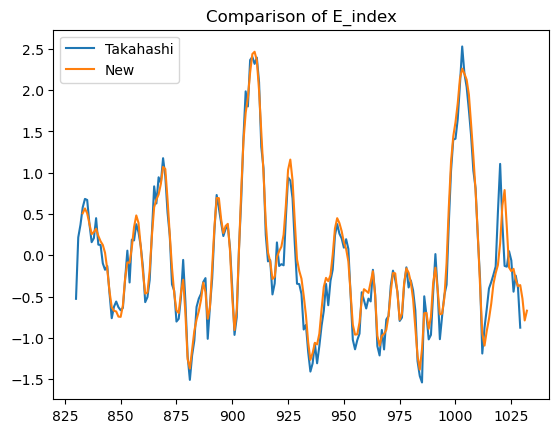

In [18]:
plt.title('Comparison of E_index')
plt.plot(taka['E_index'][-200:], label = 'Takahashi')
plt.plot(new['E_index'][-200:], label='New')
plt.legend()

In [19]:
## correlation between both

print('Correlation E_index: ', new['E_index'].corr(taka['E_index']))
print('Correlation C_index: ', new['C_index'].corr(taka['C_index']))

Correlation E_index:  0.9744731882378322
Correlation C_index:  0.9679087813622926


In [8]:
df = pd.read_csv(f"{PATH}/daily_dataframe.csv")

# # WR labels ( actual mapping)
WR_NAMES = {0: "Pacific Trough", 1: "Greenland High", 2: "Pacific Ridge", 3:"Alaskan Ridge", 4: "No Regime"}

WR_SHORT = {0: "PT", 1: "GH", 2: "PR", 3:"AR", 4: "N/A"}
WR_COLORS = {0: "#0b6fe2", 1: "#30b430", 2: "#d33131",3: "#ddf00a", 4: "#5c676f"}
WR_ORDER = [1,3,4,2, 0] # PT # PR #AR # GH # NR
WR_ORDER = [0, 2, 3, 1, 4]

df["WR_name"] = df["WR"].map(WR_NAMES)
df['date'] = pd.to_datetime(df['date'])

In [9]:
type(df['date'][4])

pandas.Timestamp

## Comparison of E/C coefficients

In [4]:
def fit_decade(sub, target):
    """Fit target = a*E + b*C + intercept. Returns dict of params."""
    m = sub[["E_index", "C_index", target]].dropna()
    if len(m) < 12:
        return None
    X = m[["E_index", "C_index"]].values
    y = m[target].values
    reg = LinearRegression().fit(X, y)
    return {
        "a": reg.coef_[0],
        "b": reg.coef_[1],
        "intercept": reg.intercept_,
        "r2": reg.score(X, y),
        "n": len(m),
        "y_obs": y,
        "y_pred": reg.predict(X),
    }

# Use monthly resolution so observations aren't artificially inflated by each day in a month getting the same E/C/RONI/ONI value
monthly = (df.groupby(["year", "month"])[["E_index", "C_index", "RONI", "ONI"]]
             .first().reset_index())
monthly["decade"] = (monthly["year"] // 10) * 10
decades = sorted(monthly["decade"].unique())

In [5]:
print("=" * 65)
print("FULL-RECORD FITS (monthly data)")
print("=" * 65)
for target in ["RONI", "ONI"]:
    f = fit_decade(monthly, target)
    print(f"{target} = {f['a']:+.3f} * E  {f['b']:+.3f} * C  {f['intercept']:+.3f}"
          f"   R^2 = {f['r2']:.3f}   n = {f['n']}")
print(f"\nTakahashi (Nino 3.4* on HadISST): 0.82 * PC1 + 0.21 * PC2")
print("those coefs are on PC1/PC2, but E/C have 45deg rotation")
print("E coeff = (a_PC1 - a_PC2)/sqrt(2),")
print("C coeff = (a_PC1 + a_PC2)/sqrt(2)")
print(f"  equivalent: E coeff = {(0.82-0.21)/np.sqrt(2):.3f},"
      f"  C coeff = {(0.82+0.21)/np.sqrt(2):.3f}")

FULL-RECORD FITS (monthly data)
RONI = +0.419 * E  +0.533 * C  +0.237   R^2 = 0.738   n = 912
ONI = +0.457 * E  +0.621 * C  +0.268   R^2 = 0.881   n = 912

Takahashi (Nino 3.4* on HadISST): 0.82 * PC1 + 0.21 * PC2
those coefs are on PC1/PC2, but E/C have 45deg rotation
E coeff = (a_PC1 - a_PC2)/sqrt(2),
C coeff = (a_PC1 + a_PC2)/sqrt(2)
  equivalent: E coeff = 0.431,  C coeff = 0.728


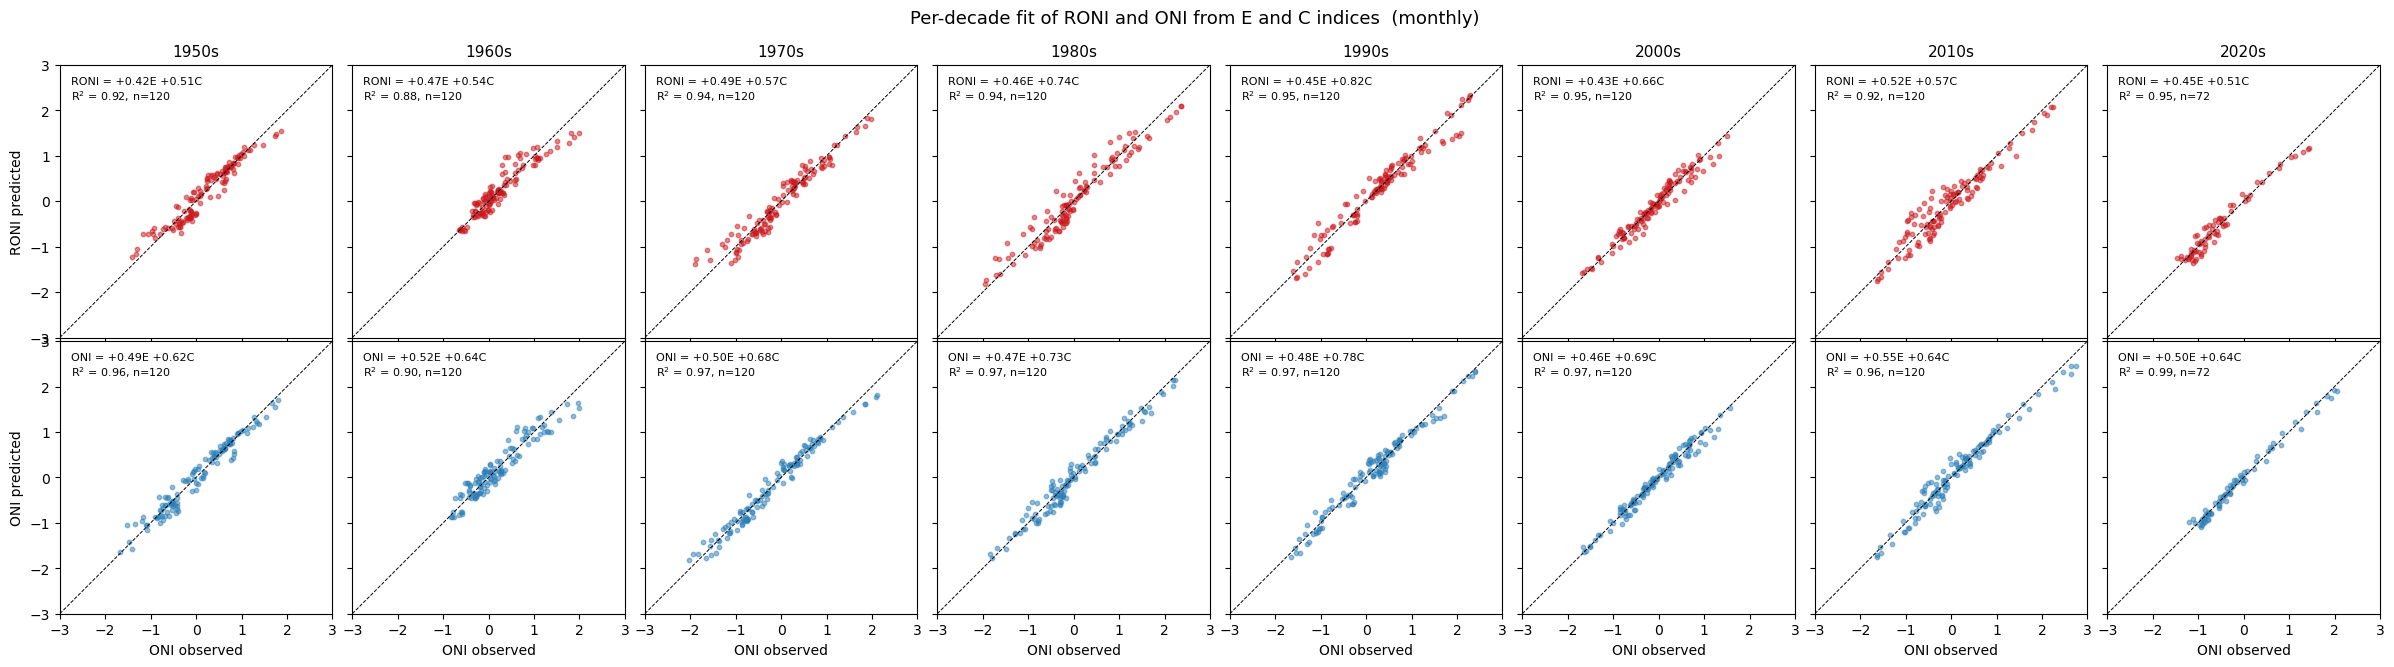

In [6]:
# ============================================================
# 2. Per-decade scatter panels
# ============================================================
n_dec = len(decades)
fig, axes = plt.subplots(2, n_dec, figsize=(3.0 * n_dec, 6.5), sharex=True, sharey=True)

results = {"RONI": [], "ONI": []}

for row, target in enumerate(["RONI", "ONI"]):
    color = "#cb181d" if target == "RONI" else "#2c7fb8"
    for col, dec in enumerate(decades):
        ax = axes[row, col]
        sub = monthly[monthly["decade"] == dec]
        f = fit_decade(sub, target)
        if f is None:
            ax.set_visible(False)
            continue
        results[target].append({"decade": dec, **{k: f[k] for k in ["a", "b", "intercept", "r2", "n"]}})

        ax.scatter(f["y_obs"], f["y_pred"], s=10, alpha=0.5, color=color)
        lims = [-3, 3]
        ax.plot(lims, lims, "k--", lw=0.7)
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")

        # Annotation
        txt = (f"{target} = {f['a']:+.2f}E {f['b']:+.2f}C\n"
               f"R$^2$ = {f['r2']:.2f}, n={f['n']}")
        ax.text(0.04, 0.96, txt, transform=ax.transAxes, va="top", ha="left",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, lw=0))

        if row == 0:
            ax.set_title(f"{int(dec)}s", fontsize=11)
        if col == 0:
            ax.set_ylabel(f"{target} predicted")
        if row == 1:
            ax.set_xlabel(f"{target} observed")

plt.suptitle("Per-decade fit of RONI and ONI from E and C indices  (monthly)",
             y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS}/fig_per_decade_fits.png", dpi=140, bbox_inches="tight")
plt.show()


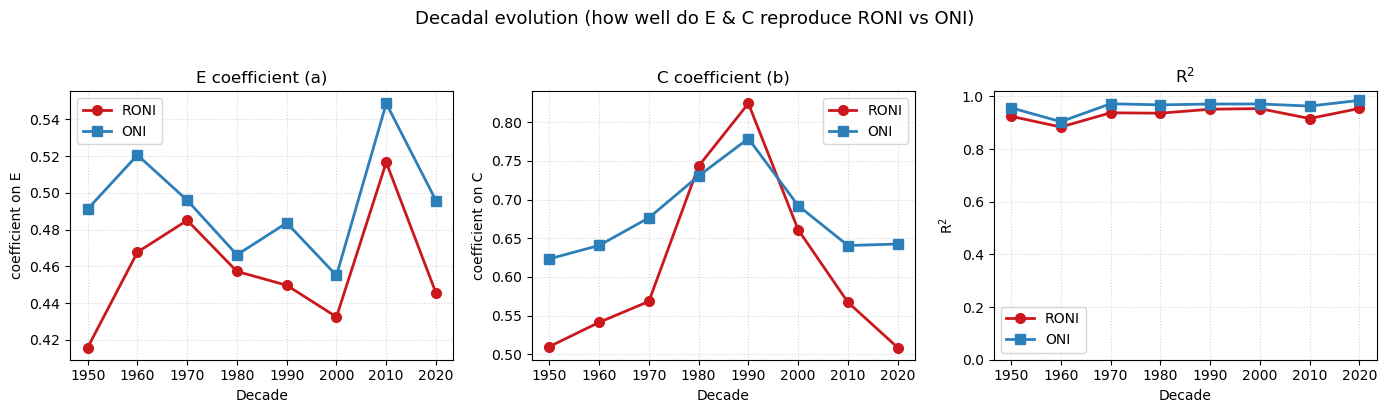

In [8]:
#Summary plot: coefficients and R^2 over time
# ============================================================
res_roni = pd.DataFrame(results["RONI"])
res_oni  = pd.DataFrame(results["ONI"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# E coefficient
axes[0].plot(res_roni["decade"], res_roni["a"], "o-", color="#cb181d",
             lw=2, markersize=7, label="RONI")
axes[0].plot(res_oni["decade"], res_oni["a"], "s-", color="#2c7fb8",
             lw=2, markersize=7, label="ONI")
axes[0].set_title("E coefficient (a)")
axes[0].set_xlabel("Decade"); axes[0].set_ylabel("coefficient on E")
axes[0].grid(ls=":", alpha=0.5); axes[0].legend()

# C coefficient
axes[1].plot(res_roni["decade"], res_roni["b"], "o-", color="#cb181d",
             lw=2, markersize=7, label="RONI")
axes[1].plot(res_oni["decade"], res_oni["b"], "s-", color="#2c7fb8",
             lw=2, markersize=7, label="ONI")
axes[1].set_title("C coefficient (b)")
axes[1].set_xlabel("Decade"); axes[1].set_ylabel("coefficient on C")
axes[1].grid(ls=":", alpha=0.5); axes[1].legend()

# R^2
axes[2].plot(res_roni["decade"], res_roni["r2"], "o-", color="#cb181d",
             lw=2, markersize=7, label="RONI")
axes[2].plot(res_oni["decade"], res_oni["r2"], "s-", color="#2c7fb8",
             lw=2, markersize=7, label="ONI")
axes[2].set_title("R$^2$")
axes[2].set_xlabel("Decade"); axes[2].set_ylabel("R$^2$")
axes[2].set_ylim(0, 1.02); axes[2].grid(ls=":", alpha=0.5); axes[2].legend()

plt.suptitle("Decadal evolution (how well do E & C reproduce RONI vs ONI)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS}/EC_index/fig_per_decade_coefs.png", dpi=140, bbox_inches="tight")
plt.show()


In [9]:
print("\n" + "=" * 65)
print("PER-DECADE FIT SUMMARY")
print("=" * 65)
for target, df_r in [("RONI", res_roni), ("ONI", res_oni)]:
    print(f"\n--- {target} ---")
    print(df_r[["decade", "a", "b", "intercept", "r2", "n"]].to_string(index=False,
        formatters={"a": "{:+.3f}".format, "b": "{:+.3f}".format,
                    "intercept": "{:+.3f}".format, "r2": "{:.3f}".format}))



PER-DECADE FIT SUMMARY

--- RONI ---
 decade      a      b intercept    r2   n
   1950 +0.416 +0.510    +0.619 0.925 120
   1960 +0.468 +0.541    +0.626 0.884 120
   1970 +0.485 +0.568    +0.568 0.938 120
   1980 +0.457 +0.743    +0.306 0.937 120
   1990 +0.450 +0.824    +0.226 0.952 120
   2000 +0.433 +0.661    +0.035 0.954 120
   2010 +0.517 +0.567    -0.174 0.916 120
   2020 +0.445 +0.509    -0.420 0.955  72

--- ONI ---
 decade      a      b intercept    r2   n
   1950 +0.491 +0.623    +0.582 0.957 120
   1960 +0.521 +0.641    +0.627 0.904 120
   1970 +0.496 +0.676    +0.469 0.972 120
   1980 +0.466 +0.731    +0.324 0.968 120
   1990 +0.484 +0.779    +0.101 0.971 120
   2000 +0.455 +0.692    +0.065 0.972 120
   2010 +0.549 +0.641    +0.011 0.964 120
   2020 +0.496 +0.642    +0.035 0.985  72



ONI = +0.454 * E_index  +0.644 * C_index  +0.028
R^2 = 0.969
coeff show how much of ONI is explained
compare to Takahashi Niño 3.4* = 0.82 PC1 + 0.21 PC2
   Takahashi-equivalent: E coeff = 0.431,  C coeff = 0.728


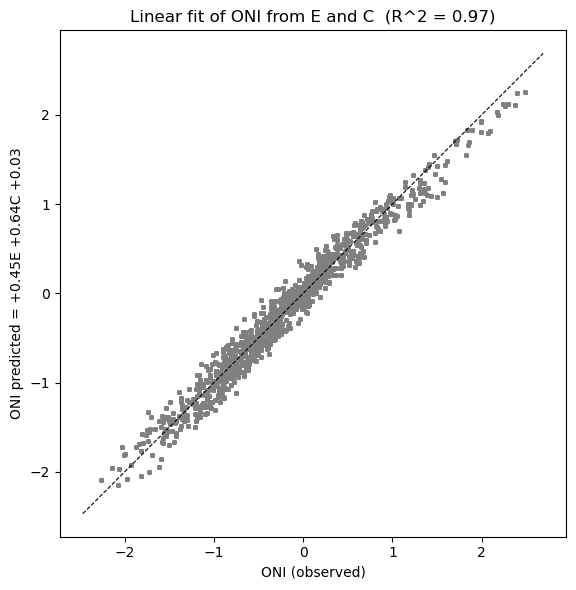

In [ ]:
mask = df[["E_index", "C_index", "ONI"]].dropna().index
X = df.loc[mask, ["E_index", "C_index"]].values
y = df.loc[mask, "ONI"].values
reg = LinearRegression().fit(X, y)
a, b = reg.coef_
intercept = reg.intercept_
r2 = reg.score(X, y)

print("\n" + "=" * 60)
print(f"ONI = {a:+.3f} * E_index  {b:+.3f} * C_index  {intercept:+.3f}")
print(f"R^2 = {r2:.3f}")
print("=" * 60)
print("coeff show how much of ONI is explained")
print('compare to Takahashi Niño 3.4* = 0.82 PC1 + 0.21 PC2')
print(f"   Takahashi-equivalent: E coeff = {(0.82-0.21)/np.sqrt(2):.3f},"
      f"  C coeff = {(0.82+0.21)/np.sqrt(2):.3f}")
# print("Roughly equal coefficients => RONI is balanced across flavors.")
# print("a >> b => RONI is biased toward eastern Pacific events.")

# Visualize the fit
fig, ax = plt.subplots(figsize=(6, 6))
y_pred = reg.predict(X)
ax.scatter(y, y_pred, s=6, alpha=0.4, color="gray")
lims = [min(y.min(), y_pred.min()) - 0.2, max(y.max(), y_pred.max()) + 0.2]
ax.plot(lims, lims, "k--", lw=0.8)
ax.set_xlabel("ONI (observed)")
ax.set_ylabel(f"ONI predicted = {a:+.2f}E {b:+.2f}C {intercept:+.2f}")
ax.set_title(f"Linear fit of ONI from E and C  (R^2 = {r2:.2f})")
ax.set_aspect("equal")
plt.tight_layout()
# plt.savefig(f"{PATH}/fig_ONI_from_EC.png", dpi=140)
plt.show()

# check ONI correlation instead of RONI


RONI = +0.395 * E_index  +0.560 * C_index  +0.234
R^2 = 0.743
coeff show how much of RONI is explained
compare to Takahashi Niño 3.4* = 0.82 PC1 + 0.21 PC2
   Takahashi-equivalent: E coeff = 0.431,  C coeff = 0.728
Roughly equal coefficients => RONI is balanced across flavors.
a >> b => RONI is biased toward eastern Pacific events.


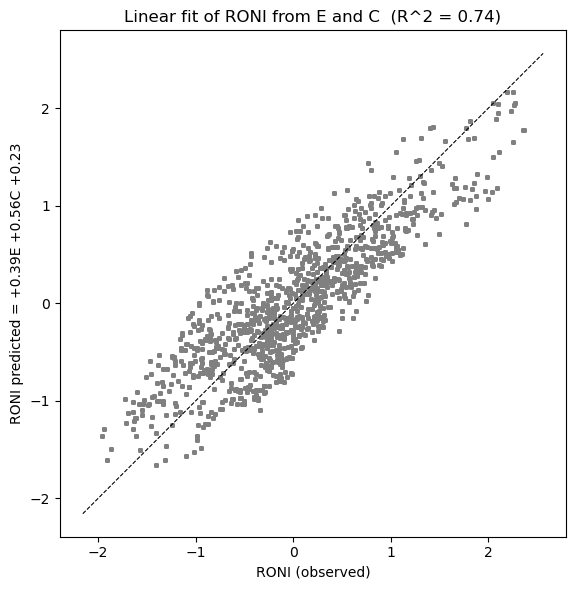

In [60]:
mask = df[["E_index", "C_index", "RONI"]].dropna().index
X = df.loc[mask, ["E_index", "C_index"]].values
y = df.loc[mask, "RONI"].values
reg = LinearRegression().fit(X, y)
a, b = reg.coef_
intercept = reg.intercept_
r2 = reg.score(X, y)

print("\n" + "=" * 60)
print(f"RONI = {a:+.3f} * E_index  {b:+.3f} * C_index  {intercept:+.3f}")
print(f"R^2 = {r2:.3f}")
print("=" * 60)
print("coeff show how much of RONI is explained")
print('compare to Takahashi Niño 3.4* = 0.82 PC1 + 0.21 PC2')
print(f"   Takahashi-equivalent: E coeff = {(0.82-0.21)/np.sqrt(2):.3f},"
      f"  C coeff = {(0.82+0.21)/np.sqrt(2):.3f}")
print("Roughly equal coefficients => RONI is balanced across flavors.")
print("a >> b => RONI is biased toward eastern Pacific events.")

# Visualize the fit
fig, ax = plt.subplots(figsize=(6, 6))
y_pred = reg.predict(X)
ax.scatter(y, y_pred, s=6, alpha=0.4, color="gray")
lims = [min(y.min(), y_pred.min()) - 0.2, max(y.max(), y_pred.max()) + 0.2]
ax.plot(lims, lims, "k--", lw=0.8)
ax.set_xlabel("RONI (observed)")
ax.set_ylabel(f"RONI predicted = {a:+.2f}E {b:+.2f}C {intercept:+.2f}")
ax.set_title(f"Linear fit of RONI from E and C  (R^2 = {r2:.2f})")
ax.set_aspect("equal")
plt.tight_layout()
# plt.savefig(f"{PATH}/fig_ONI_from_EC.png", dpi=140)
plt.show()

# check ONI correlation instead of RONI

In [10]:
from scipy.signal import detrend
# check it detrended - RONI is closer 

mfit = monthly.dropna(subset=["E_index", "C_index", "RONI", "ONI"]).copy()
mfit["ONI_dt"]  = detrend(mfit["ONI"].values)
mfit["RONI_dt"] = detrend(mfit["RONI"].values)

for target in ["ONI", "ONI_dt", "RONI", "RONI_dt"]:
    f = fit_decade(mfit, target)
    print(f"{target:10s}: R^2 = {f['r2']:.3f}   a={f['a']:+.3f}  b={f['b']:+.3f}")

    

ONI       : R^2 = 0.881   a=+0.457  b=+0.621
ONI_dt    : R^2 = 0.887   a=+0.458  b=+0.623
RONI      : R^2 = 0.738   a=+0.419  b=+0.533
RONI_dt   : R^2 = 0.853   a=+0.433  b=+0.572


TypeError: Invalid comparison between dtype=str and Timestamp

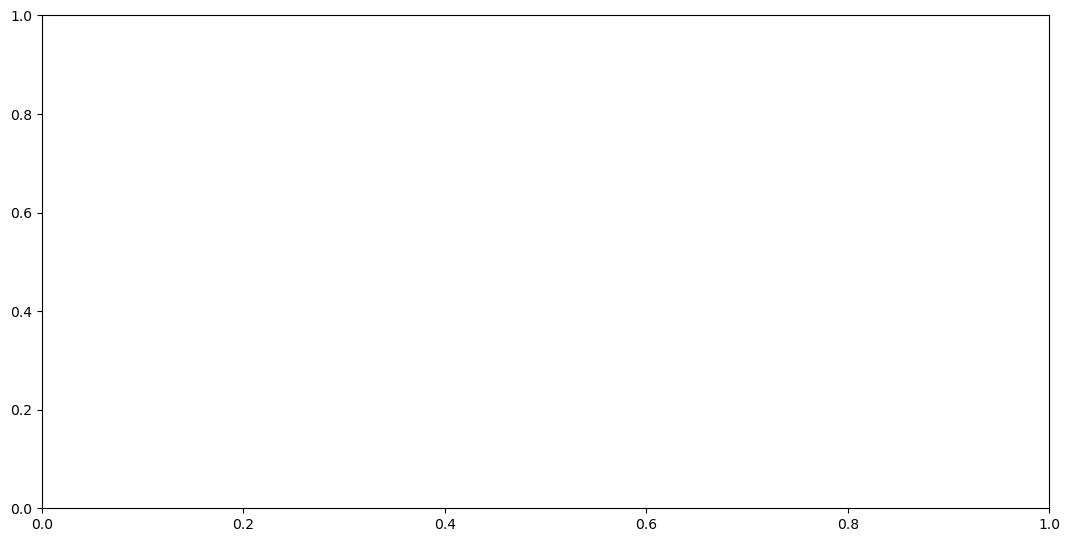

In [5]:
# representative events

# selected by index
events = [
    ("1982-1983", "strong El Nino (E-flavored)"),
    ("1997-1998", "strong El Nino (E-flavored)"),
    ("2015-2016", "strong El Nino"),
    ("2009-2010", "moderate El Nino (C-flavored)"),
    ("2002-2003", "moderate El Nino"),
    ("1988-1989", "strong La Nina"),
    ("1999-2000", "strong La Nina"),
    ("2010-2011", "strong La Nina"),
    ("1993-1994", "neutral"),
]

fig, ax = plt.subplots(figsize=(13, len(events) * 0.6 + 1))
for i, (label, descrip) in enumerate(events):
    y0 = int(label.split("-")[0]); y1 = int(label.split("-")[1])
    start = pd.Timestamp(f"{y0}-10-01"); end = pd.Timestamp(f"{y1}-03-31")
    sub = df[(df["date"] >= start) & (df["date"] <= end)]
    if sub.empty: continue
    # Plot each day as a small colored square
    for wr_val, color in WR_COLORS.items():
        m = sub["WR"] == wr_val
        ax.scatter(sub.loc[m, "date"].apply(lambda d: (d - start).days),
                   np.full(m.sum(), i), c=color, s=12, marker="s")
    # RONI annotation
    mean_roni = sub["RONI"].mean()
    ax.text(-5, i, f"{label}\n{descrip}\nRONI={mean_roni:+.2f}",
            ha="right", va="center", fontsize=8)

ax.set_yticks([]); ax.set_ylim(-0.5, len(events) - 0.5)
ax.set_xlim(-50, 200)
ax.set_xlabel("Days from October 1")
# Add month tick marks
month_offsets = [0, 31, 62, 92, 123, 154, 182]
month_labels  = ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr"]
ax.set_xticks(month_offsets); ax.set_xticklabels(month_labels)
ax.set_title("Daily weather regimes during ONDJFM of selected ENSO events")
# Legend
handles = [plt.scatter([], [], c=c, s=40, marker="s", label=WR_NAMES[w])
           for w, c in WR_COLORS.items()]
ax.legend(handles=handles, loc="lower right", ncol=4, fontsize=9, frameon=True)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{PATH}/fig_event_timeseries.png", dpi=140, bbox_inches="tight")
plt.show()


In [116]:
## sample size table

table = df.groupby(["season", "roni_state", "WR_name"]).size().unstack("WR_name", fill_value=0)
table["TOTAL"] = table.sum(axis=1)
print("\n" + "=" * 70)
print("SAMPLE-SIZE TABLE (daily counts) on RONI-based ENSO state")
print("=" * 70)
for s in ["DJF", "MAM", "JJA", "SON"]:
    if s in table.index.get_level_values(0):
        print(f"\n--- {s} ---")
        print(table.loc[s].reindex(state_order))

# table.to_csv(f"{PATH}/sample_sizes_RONI_state.csv")



SAMPLE-SIZE TABLE (daily counts) on RONI-based ENSO state

--- DJF ---
WR_name         Alaskan Ridge  Greenland High  No Regime  Pacific Ridge  \
roni_state                                                                
strong La Nina            238             196        150            334   
weak La Nina              231             157        134            249   
neutral                   632             628        349            709   
weak El Nino              268             215        164            239   
strong El Nino            194             320        129            114   

WR_name         Pacific Trough  TOTAL  
roni_state                             
strong La Nina             286   1204  
weak La Nina               309   1080  
neutral                    671   2989  
weak El Nino               343   1229  
strong El Nino             481   1238  

--- MAM ---
WR_name         Alaskan Ridge  Greenland High  No Regime  Pacific Ridge  \
roni_state                        

In [13]:
# changed from RONI -> ONI

# def assign_3state(group):
#     p25, p75 = group["RONI"].quantile([0.25, 0.75])
#     state = np.where(group["RONI"] <= p25, "La Nina",
#             np.where(group["RONI"] >= p75, "El Nino", "Neutral"))
#     return pd.Series(state, index=group.index)

# df["enso_3state"] = df.groupby("month", group_keys=False).apply(assign_3state)



state3_order  = ["La Nina", "neutral", "El Nino"]
state3_colors = {"La Nina": "#2c7fb8", "neutral": "#bdbdbd", "El Nino": "#cb181d"}


# change to seasonal weighing


In [15]:
def block_bootstrap_freq(sub, n_boot=1000, seed=0):
    """Return dict: {wr_val: (lower95, upper95)} for conditional frequency."""
    rng = np.random.default_rng(seed)
    years = sub["year"].unique()
    n_total = len(sub)
    results = {w: [] for w in WR_ORDER}
    # Pre-group by year for fast resampling
    by_year = {y: sub[sub["year"] == y] for y in years}
    for _ in range(n_boot):
        sampled_years = rng.choice(years, size=len(years), replace=True)
        boot = pd.concat([by_year[y] for y in sampled_years])
        total = len(boot)
        for w in WR_ORDER:
            results[w].append((boot["WR"] == w).sum() / total * 100 if total else np.nan)
    return {w: (np.nanpercentile(results[w], 2.5),
                np.nanpercentile(results[w], 97.5)) for w in WR_ORDER}

In [1]:
# df_full = df

start_date = '1950-01-01'
end_date = '2025-12-31'

subset_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

NameError: name 'df' is not defined

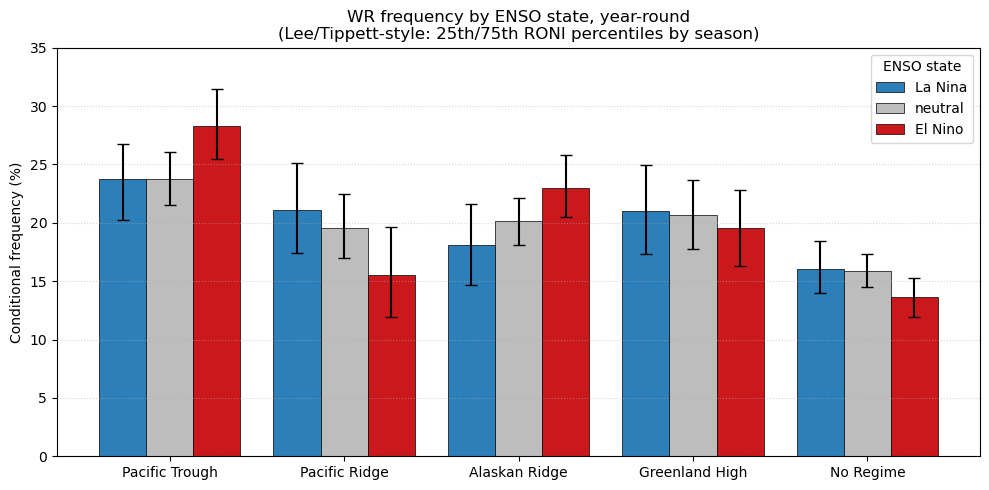

In [19]:

fig, ax = plt.subplots(figsize=(10, 5))

freqs, ci_lo, ci_hi = {}, {}, {}
for state in state3_order:
    sub = subset_df[subset_df["ONI_state"] == state]
    freqs[state] = {w: (sub["WR"] == w).sum() / len(sub) * 100 for w in WR_ORDER}
    ci = block_bootstrap_freq(sub, n_boot=500)
    ci_lo[state] = {w: freqs[state][w] - ci[w][0] for w in WR_ORDER}
    ci_hi[state] = {w: ci[w][1] - freqs[state][w] for w in WR_ORDER}

x = np.arange(len(WR_ORDER))
width = 0.27
for i, state in enumerate(state3_order):
    vals = [freqs[state][w] for w in WR_ORDER]
    errs = [[ci_lo[state][w] for w in WR_ORDER],
            [ci_hi[state][w] for w in WR_ORDER]]
    ax.bar(x + (i - 1) * width, vals, width, yerr=errs, capsize=4,
           color=state3_colors[state], label=state, edgecolor="k", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([WR_NAMES[w] for w in WR_ORDER])
ax.set_ylabel("Conditional frequency (%)")
ax.set_title("WR frequency by ENSO state, year-round\n"
             "(Lee/Tippett-style: 25th/75th RONI percentiles by season)")
ax.legend(title="ENSO state")
ax.set_ylim(0, 35)
ax.grid(axis="y", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

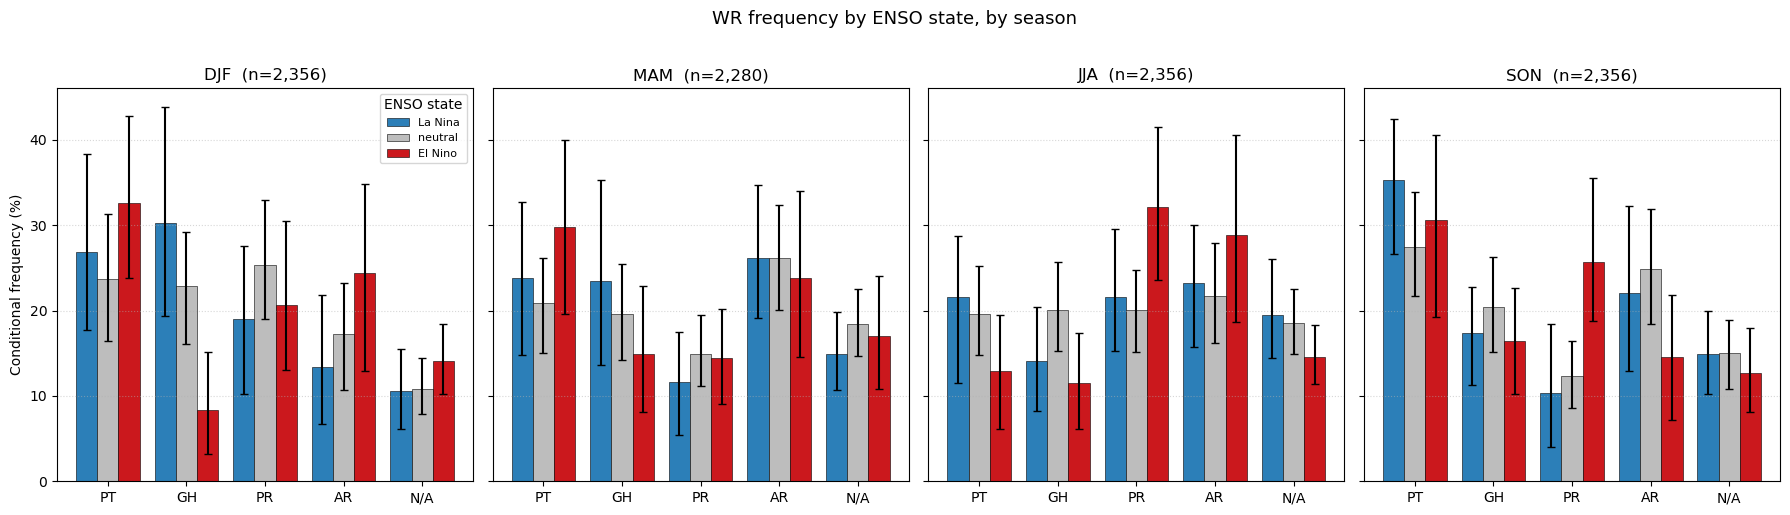

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for ax, season in zip(axes, ["DJF", "MAM", "JJA", "SON"]):
    sub_s = df[df["season"] == season]
    for i, state in enumerate(state3_order):
        sub = sub_s[sub_s["ONI_state"] == state]
        if len(sub) == 0: continue
        vals = [(sub["WR"] == w).sum() / len(sub) * 100 for w in WR_ORDER]
        ci = block_bootstrap_freq(sub, n_boot=300)
        errs = [[vals[k] - ci[w][0] for k, w in enumerate(WR_ORDER)],
                [ci[w][1] - vals[k] for k, w in enumerate(WR_ORDER)]]
        ax.bar(x + (i - 1) * width, vals, width, yerr=errs, capsize=3,
               color=state3_colors[state],
               label=state if season == "DJF" else None,
               edgecolor="k", linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(WR_SHORT.values())
    ax.set_title(f"{season}  (n={len(sub_s):,})")
    ax.grid(axis="y", ls=":", alpha=0.5)
    if season == "DJF":
        ax.set_ylabel("Conditional frequency (%)")
        ax.legend(title="ENSO state", fontsize=8)
plt.suptitle("WR frequency by ENSO state, by season", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS}/freq_by_ONI_by_season.png", dpi=140, bbox_inches="tight")
plt.show()

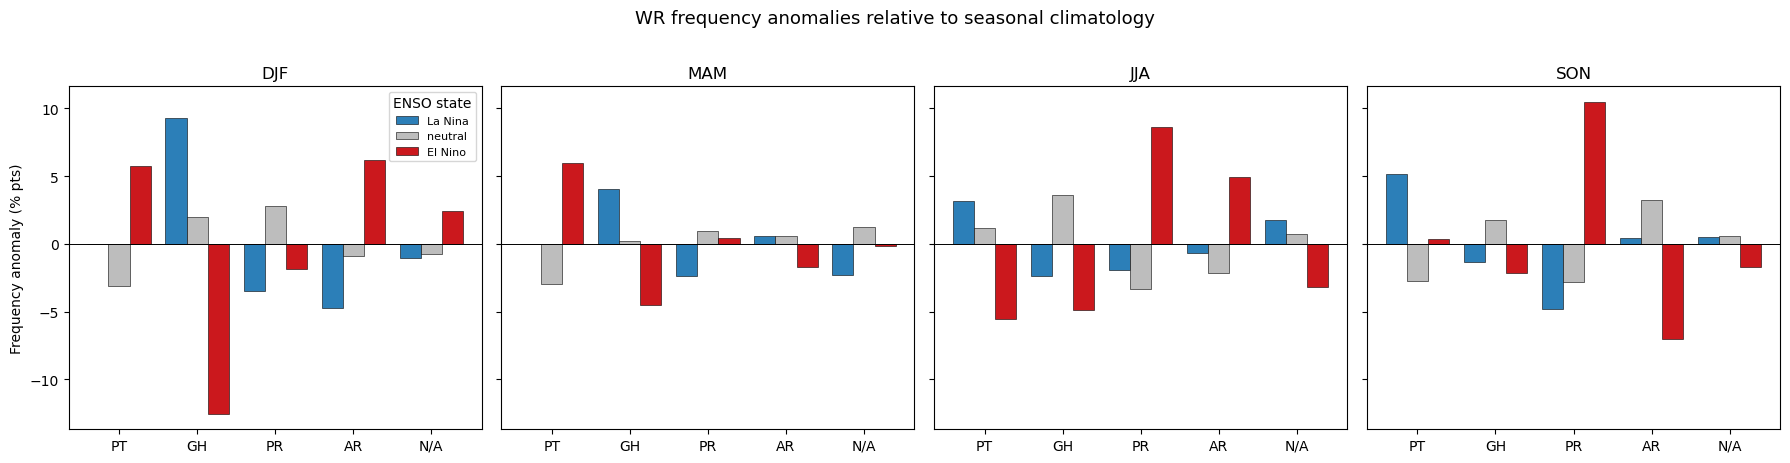

In [25]:
# ============================================================
# Frequency anomalies rel to each WR's marginal climatology
# the anomaly is conditional freq minus the WR's overall freq within that season
# shows whether ENSO state shifts the distribution
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, season in zip(axes, ["DJF", "MAM", "JJA", "SON"]):
    sub_s = df[df["season"] == season]
    clim = {w: (sub_s["WR"] == w).sum() / len(sub_s) * 100 for w in WR_ORDER}
    for i, state in enumerate(state3_order):
        sub = sub_s[sub_s["ONI_state"] == state]
        if len(sub) == 0: continue
        anom = [((sub["WR"] == w).sum() / len(sub) * 100) - clim[w] for w in WR_ORDER]
        ax.bar(x + (i - 1) * width, anom, width,
               color=state3_colors[state],
               label=state if season == "DJF" else None,
               edgecolor="k", linewidth=0.4)
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xticks(x); ax.set_xticklabels(WR_SHORT.values())
    ax.set_title(season)
    if season == "DJF":
        ax.set_ylabel("Frequency anomaly (% pts)")
        ax.legend(title="ENSO state", fontsize=8)
plt.suptitle("WR frequency anomalies relative to seasonal climatology",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS}/fig_freq_anomaly_by_season.png", dpi=140, bbox_inches="tight")
plt.show()

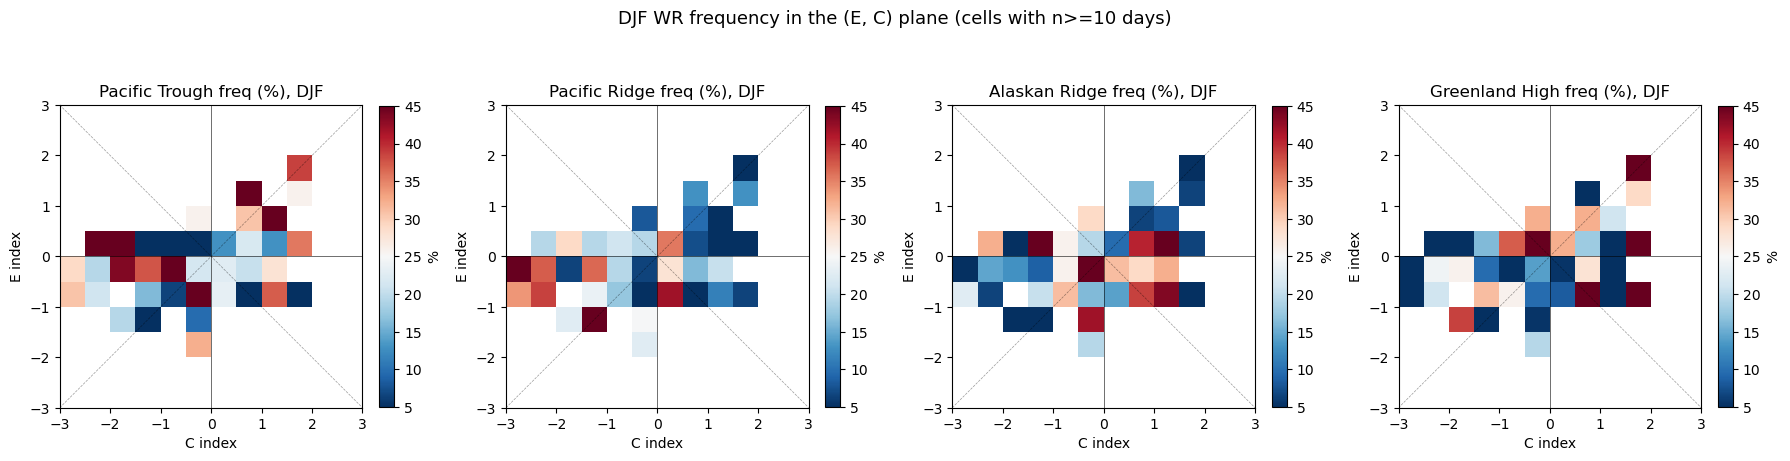

In [27]:
# Heatmap of WR frequency across the (E,C) plane (for DJF)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
e_bins = np.linspace(-3, 3, 13)
c_bins = np.linspace(-3, 3, 13)
djf = df[df["season"] == "DJF"]
h_total, _, _ = np.histogram2d(djf["E_index"], djf["C_index"], bins=[e_bins, c_bins])

for ax, w in zip(axes, WR_ORDER):
    h_wr, _, _ = np.histogram2d(djf[djf["WR"] == w]["E_index"],
                                djf[djf["WR"] == w]["C_index"],
                                bins=[e_bins, c_bins])
    with np.errstate(invalid="ignore", divide="ignore"):
        freq = np.where(h_total >= 10, h_wr / h_total * 100, np.nan)
    im = ax.pcolormesh(c_bins, e_bins, freq, cmap="RdBu_r", vmin=5, vmax=45)
    ax.axhline(0, color="k", lw=0.4); ax.axvline(0, color="k", lw=0.4)
    # E and C axes annotation (PCs rotated 45)
    ax.plot([-3, 3], [3, -3], "k--", lw=0.5, alpha=0.4)
    ax.plot([-3, 3], [-3, 3], "k--", lw=0.5, alpha=0.4)
    ax.set_xlabel("C index"); ax.set_ylabel("E index")
    ax.set_title(f"{WR_NAMES[w]} freq (%), DJF")
    ax.set_aspect("equal"); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    plt.colorbar(im, ax=ax, fraction=0.045, label="%")
plt.suptitle("DJF WR frequency in the (E, C) plane (cells with n>=10 days)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f"{PATH}/fig_EC_plane_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

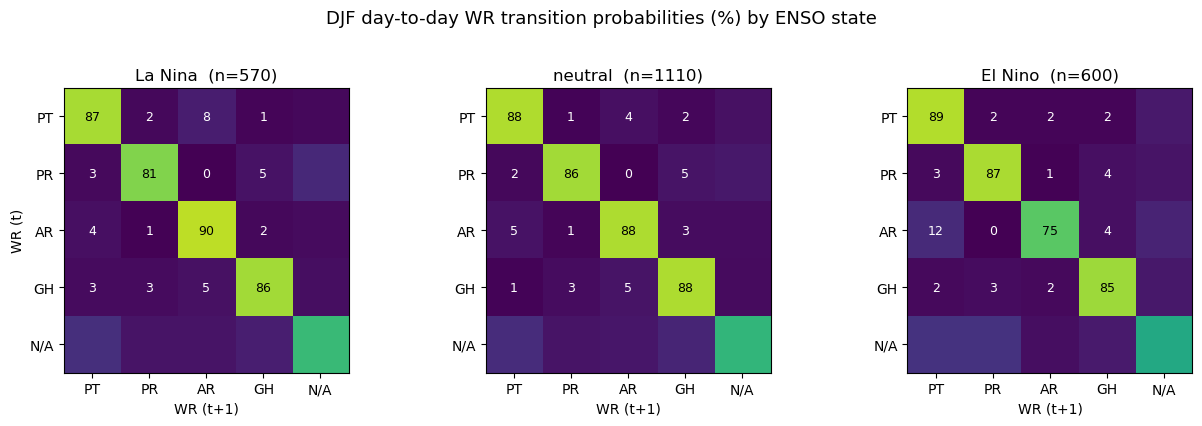


DJF day-to-day persistence (diagonal of transition matrix):
  La Nina:
    PT:  86.9%   (n=153)
    PR:  90.1%   (n=172)
    AR:  86.0%   (n=107)
    GH:  81.0%   (n=79)
    N/A:  67.8%   (n=59)
  neutral:
    PT:  88.2%   (n=262)
    PR:  87.8%   (n=254)
    AR:  87.5%   (n=281)
    GH:  86.2%   (n=196)
    N/A:  65.8%   (n=117)
  El Nino:
    PT:  88.7%   (n=194)
    PR:  74.5%   (n=51)
    AR:  85.5%   (n=124)
    GH:  87.2%   (n=148)
    N/A:  60.2%   (n=83)


In [51]:
# ============================================================
# 6. Transition probabilities (DJF) by 3-state ENSO
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, state in zip(axes, state3_order):
    sub = df[(df["season"] == "DJF") & (df["ONI_state"] == state)].sort_values("date").copy()
    sub["date"] = pd.to_datetime(sub["date"])
    sub["WR_next"]   = sub["WR"].shift(-1)
    sub["next_date"] = sub["date"].shift(-1)
    
    consecutive = (sub["next_date"] - sub["date"]).dt.days == 1
    sub = sub[consecutive]
    tm = (pd.crosstab(sub["WR"], sub["WR_next"], normalize="index") * 100
            )
    im = ax.imshow(tm.values, cmap="viridis", vmin=0, vmax=100)
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels([WR_SHORT[w] for w in WR_ORDER])
    ax.set_yticklabels([WR_SHORT[w] for w in WR_ORDER])
    ax.set_xlabel("WR (t+1)")
    if state == "La Nina":
        ax.set_ylabel("WR (t)")
    ax.set_title(f"{state}  (n={len(sub)})")
    for i in range(4):
        for j in range(4):
            v = tm.values[i, j]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="white" if v < 50 else "black", fontsize=9)
plt.suptitle("DJF day-to-day WR transition probabilities (%) by ENSO state",
             y=1.04, fontsize=13)
plt.tight_layout()
# plt.savefig(f"{RESULTS}/fig_transitions.png", dpi=140, bbox_inches="tight")
plt.show()

# Diagonal = persistence summary
print("\nDJF day-to-day persistence (diagonal of transition matrix):")
for state in state3_order:
    sub = df[(df["season"] == "DJF") & (df["ONI_state"] == state)].sort_values("date").copy()
    sub["date"] = pd.to_datetime(sub["date"])
    sub["WR_next"] = sub["WR"].shift(-1)
    sub["next_date"] = sub["date"].shift(-1)
    sub = sub[(sub["next_date"] - sub["date"]).dt.days == 1]
    print(f"  {state}:")
    for w in WR_ORDER:
        sub_w = sub[sub["WR"] == w]
        p = (sub_w["WR_next"] == w).sum() / len(sub_w) * 100 if len(sub_w) else np.nan
        print(f"    {WR_SHORT[w]}: {p:5.1f}%   (n={len(sub_w)})")


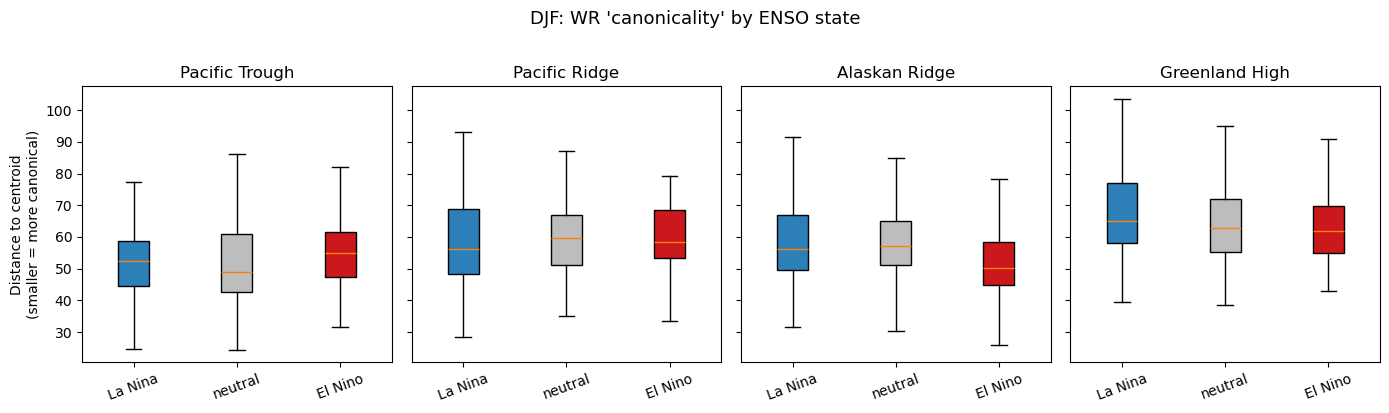

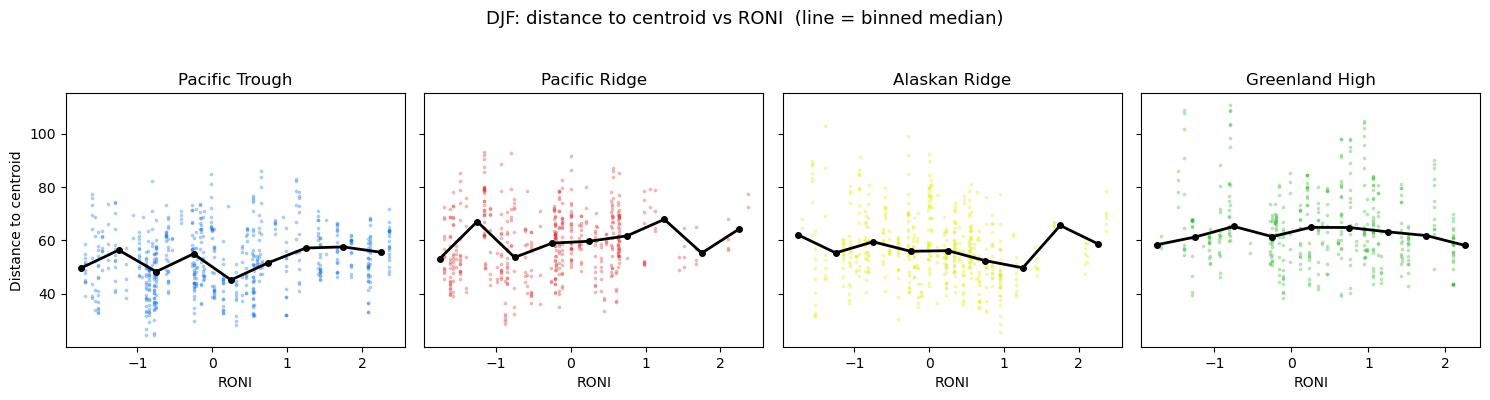

In [46]:
# ============================================================
# 7. Distance-to-centroid by ENSO state (DJF)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, w in zip(axes, WR_ORDER):
    sub = df[(df["season"] == "DJF") & (df["WR"] == w)]
    parts = [sub[sub["ONI_state"] == s]["distances"].values for s in state3_order]
    bp = ax.boxplot(parts, tick_labels=state3_order, showfliers=False, patch_artist=True)
    for patch, s in zip(bp["boxes"], state3_order):
        patch.set_facecolor(state3_colors[s])
    ax.set_title(WR_NAMES[w]); ax.tick_params(axis="x", rotation=20)
    if w == WR_ORDER[0]:
        ax.set_ylabel("Distance to centroid\n(smaller = more canonical)")
plt.suptitle("DJF: WR 'canonicality' by ENSO state", y=1.02, fontsize=13)
plt.tight_layout()
# plt.savefig(f"{RESULTS}/fig_distance_to_centroid.png", dpi=140, bbox_inches="tight")
plt.show()

# Also: scatter of distance vs RONI per WR (continuous version)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, w in zip(axes, WR_ORDER):
    sub = df[(df["season"] == "DJF") & (df["WR"] == w)]
    ax.scatter(sub["RONI"], sub["distances"], s=3, alpha=0.25, c=WR_COLORS[w])
    # binned medians
    bins = np.linspace(-2.5, 2.5, 11)
    sub_binned = sub.copy()
    sub_binned["bin"] = pd.cut(sub_binned["RONI"], bins)
    med = sub_binned.groupby("bin", observed=True)["distances"].median()
    centers = [(b.left + b.right) / 2 for b in med.index]
    ax.plot(centers, med.values, "k-o", lw=2, markersize=4)
    ax.set_title(WR_NAMES[w]); ax.set_xlabel("RONI")
    if w == WR_ORDER[0]:
        ax.set_ylabel("Distance to centroid")
plt.suptitle("DJF: distance to centroid vs RONI  (line = binned median)",
             y=1.04, fontsize=13)
plt.tight_layout()
# plt.savefig(f"{RESULTS}/fig_distance_vs_RONI.png", dpi=140, bbox_inches="tight")
plt.show()

In [53]:
df

,date,WR,distances,year,month,E_index,C_index,RONI,ONI,season,WR_name,decade,ONI_state,RONI_state
0,1950-01-01,2,71.367786,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
1,1950-01-02,2,69.577674,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
2,1950-01-03,2,67.044385,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
3,1950-01-04,2,64.494670,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
4,1950-01-05,2,62.762696,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27735,2025-12-27,4,63.899119,2025,12,-0.788619,-0.270784,-1.030603,-0.54,NDJ,No Regime,2020,neutral,strong La Nina
27736,2025-12-28,1,57.189714,2025,12,-0.788619,-0.270784,-1.030603,-0.54,NDJ,Greenland High,2020,neutral,strong La Nina
27737,2025-12-29,1,48.719027,2025,12,-0.788619,-0.270784,-1.030603,-0.54,NDJ,Greenland High,2020,neutral,strong La Nina
27738,2025-12-30,1,46.044778,2025,12,-0.788619,-0.270784,-1.030603,-0.54,NDJ,Greenland High,2020,neutral,strong La Nina


In [54]:
# thresholds 1 sigmain either direction

sigma_E = df["E_index"].std()
sigma_C = df["C_index"].std()
print(f"\nsigma_E = {sigma_E},  sigma_C = {sigma_C}")

def enso_state(row, sE=sigma_E, sC=sigma_C):
    E, C = row["E_index"], row["C_index"]
    # E-warm: extreme warm regime, dom E component
    if E > sE and E > abs(C):
        return "E-warm"
    # E-cold (should be rare)
    if E < -sE and abs(E) > abs(C):
        return "E-cold"
    # C-warm: moderate warm in central Pacific
    if C > sC and abs(E) < sE:
        return "C-warm"
    # C-cold: captures La Nina
    if C < -sC and abs(E) < sE:
        return "C-cold"
    return "neutral"

df["enso_state"] = df.apply(enso_state, axis=1)



sigma_E = 0.9594788670524512,  sigma_C = 0.9492003417214324


In [57]:
df.columns

Index(['date', 'WR', 'distances', 'year', 'month', 'E_index', 'C_index',
       'RONI', 'ONI', 'season', 'WR_name', 'decade', 'ONI_state', 'RONI_state',
       'enso_state'],
      dtype='str')

In [55]:
# ## sapmle size table

table = df.groupby(["season", "enso_state", "WR_name"]).size().unstack("WR_name", fill_value=0)
table["TOTAL"] = table.sum(axis=1)
print("\n" + "="*70)
print("Daily Count of Distribution")
print("="*70)
for s in ["DJF", "MAM", "JJA", "SON"]:
    print(f"\n--- {s} ---")
    print(table.loc[s] if s in table.index.get_level_values(0) else "(no data)")



Daily Count of Distribution

--- DJF ---
WR_name     Alaskan Ridge  Greenland High  No Regime  Pacific Ridge  \
enso_state                                                            
C-cold                104              87         49            177   
C-warm                 87              66         45             28   
E-cold                 55              17         25             30   
E-warm                 14              25         17             10   
neutral               270             233        137            248   

WR_name     Pacific Trough  TOTAL  
enso_state                         
C-cold                 203    620  
C-warm                 115    341  
E-cold                  28    155  
E-warm                  58    124  
neutral                228   1116  

--- MAM ---
WR_name     Alaskan Ridge  Greenland High  No Regime  Pacific Ridge  \
enso_state                                                            
C-cold                 55             117         76 

In [ ]:
# table.to_csv(f"/Users/kaijz/Desktop/NOAA/ensoregimes/ensoregimes/results/sample_sizes_WR_x_ENSO_x_season.csv")


Time Series plots